<a href="https://colab.research.google.com/github/abeonaadiona1-submission/A2-system-benchmark/blob/main/Benchmark_sim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


STARTING EXPERIMENT WITH SOTA BASELINES
Config: A2_Full

TRAINING FULL SYSTEM (25-STEP HORIZON + NOISE + CLIPPING)
  Ep 0: Loss=5.1242
  Ep 25: Loss=2.8902
  Ep 50: Loss=2.1855
  Ep 75: Loss=2.2084
  Ep 100: Loss=3.0646
  Ep 125: Loss=2.4239
  Seed 42: ADE=2.2800, FDE=4.2194, Viols=0
  Seed 101: ADE=2.3939, FDE=4.4506, Viols=0
  Seed 2024: ADE=2.3252, FDE=4.3110, Viols=0
  Seed 7: ADE=2.3792, FDE=4.4255, Viols=0
  Seed 99: ADE=2.3216, FDE=4.2944, Viols=4
  Seed 123: ADE=2.3819, FDE=4.4243, Viols=0
  Seed 456: ADE=2.3716, FDE=4.3917, Viols=0
  Seed 789: ADE=2.3229, FDE=4.3132, Viols=0
Config: MAPPO
  Seed 42: ADE=9.0947, FDE=15.8543, Viols=402
  Seed 101: ADE=8.0359, FDE=14.1794, Viols=644
  Seed 2024: ADE=5.6274, FDE=9.3822, Viols=201
  Seed 7: ADE=7.9218, FDE=13.6713, Viols=437
  Seed 99: ADE=6.9040, FDE=11.6891, Viols=340
  Seed 123: ADE=7.1356, FDE=12.5669, Viols=221
  Seed 456: ADE=6.7124, FDE=11.6533, Viols=298
  Seed 789: ADE=7.4073, FDE=12.8205, Viols=326
Config: MAT
  Seed 42:

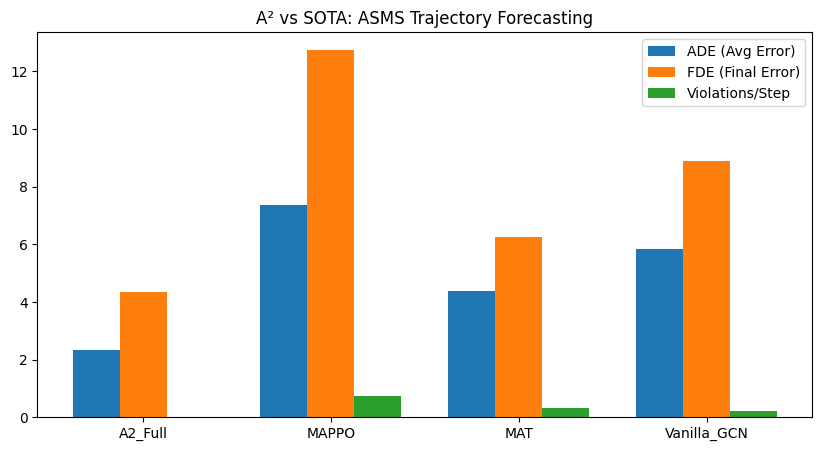

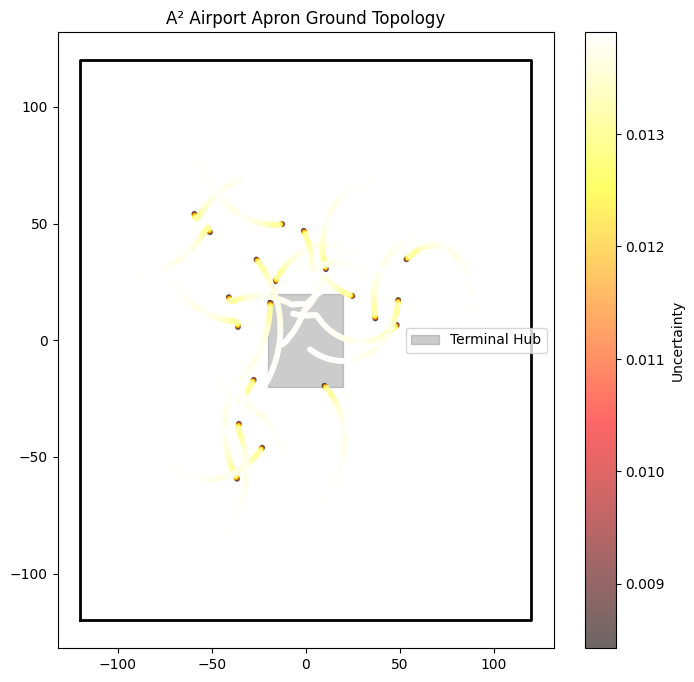

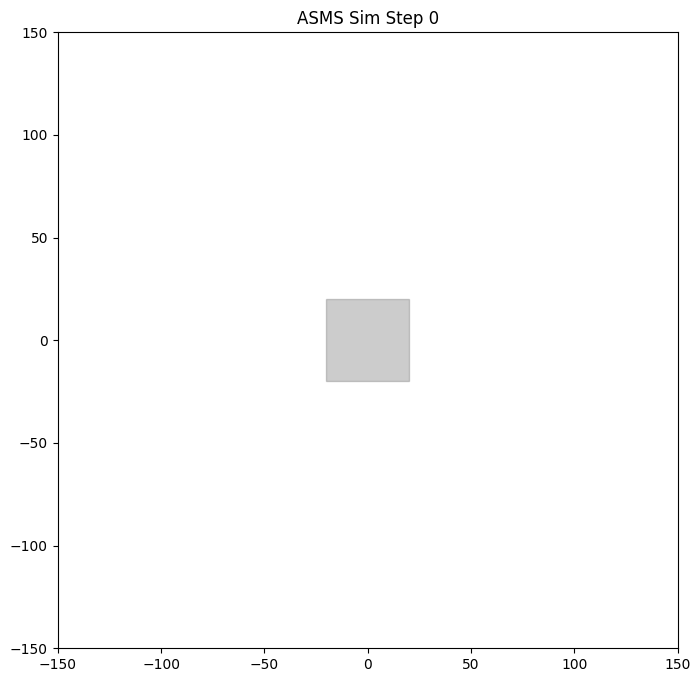

In [1]:

!pip install -q networkx matplotlib
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import networkx as nx
from networkx.algorithms.flow import maximum_flow
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import random

class Colors:
    HEADER = '\033[95m'; BLUE = '\033[94m'; GREEN = '\033[92m'
    WARNING = '\033[93m'; FAIL = '\033[91m'; ENDC = '\033[0m'; BOLD = '\033[1m'

CONFIG = {
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'agents': 25,
    'state_dim': 25,
    'action_dim': 3,
    'hidden_dim': 128,
    'comm_dim': 4,
    'g0_dim': 16,
    'dt': 0.1,
    'safety_dist': 5.0,
    'max_accel': 3.0,
    'tau_unc': 0.15,
    'lambda_physics': 0.2,
    'lambda_sep': 0.1,
    'sim_steps': 150,
    'bounds': 120.0,
    'forward_sim_steps': 5,
    'resources': 5,
    'weather_mu': 1.0,
    'train_epochs': 150,
    'train_lr': 1e-3,
    'telepathy_scales': [0.5, 0.3, 0.2],
    'horizon': 25,
    'obs_noise': 0.5
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def print_header(msg):
    print(f"\n{Colors.HEADER}{Colors.BOLD}{'='*80}\n{msg}\n{'='*80}{Colors.ENDC}")

def gather_features(feats, indices):
    indices_exp = indices.unsqueeze(-1).expand(-1, -1, feats.shape[-1])
    return torch.gather(feats, 1, indices_exp)

def scatter_mean(src, index, dim_size):
    B, num_src, F_dim = src.shape
    out = torch.zeros(B, dim_size, F_dim, device=src.device)
    index_exp = index.unsqueeze(-1).expand(-1, -1, F_dim)
    out.scatter_add_(1, index_exp, src)

    count = torch.zeros(B, dim_size, F_dim, device=src.device)
    ones = torch.ones_like(src)
    count.scatter_add_(1, index_exp, ones)
    count = count.clamp(min=1e-6)
    return out / count

def build_hyperedge_indices(pos):
    B, N, _ = pos.shape
    dist = torch.cdist(pos, pos)
    ks = [3, 5, 10]
    edge_indices = []
    for k in ks:
        _, indices = dist.topk(k + 1, largest=False, dim=-1)
        node_ids = indices[:, :, 1:].reshape(B, -1)
        hyperedge_ids = torch.arange(N, device=pos.device).unsqueeze(0).repeat(B, 1)
        hyperedge_ids = hyperedge_ids.unsqueeze(-1).expand(-1, -1, k).reshape(B, -1)
        edge_index = torch.stack([node_ids, hyperedge_ids], dim=0)
        edge_indices.append(edge_index)
    return edge_indices

class HypergraphConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.node_to_edge = nn.Linear(in_c, out_c)
        self.edge_to_node = nn.Linear(out_c, out_c)
        self.norm = nn.LayerNorm(out_c)

    def forward(self, x, edge_index_list):
        B, N, _ = x.shape
        node_update = torch.zeros_like(x)
        x_trans_node = self.node_to_edge(x)

        for edge_index in edge_index_list:
            src, tgt = edge_index
            x_trans = gather_features(x_trans_node, src)
            edge_feats = scatter_mean(x_trans, tgt, dim_size=N)
            edge_trans = self.edge_to_node(edge_feats)
            edge_trans_gathered = gather_features(edge_trans, tgt)
            node_up = scatter_mean(edge_trans_gathered, src, dim_size=N)
            node_update += node_up
        return self.norm(x + F.relu(node_update))

class LDFormer(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Linear(CONFIG['state_dim'] + CONFIG['comm_dim'] + CONFIG['g0_dim'], CONFIG['hidden_dim'])
        self.hc1 = HypergraphConv(CONFIG['hidden_dim'], CONFIG['hidden_dim'])
        self.hc2 = HypergraphConv(CONFIG['hidden_dim'], CONFIG['hidden_dim'])
        self.gru = nn.GRU(CONFIG['hidden_dim'], CONFIG['hidden_dim'], batch_first=True)
        self.phys_head = nn.Linear(CONFIG['hidden_dim'], 6 * CONFIG['horizon'])
        nn.init.zeros_(self.phys_head.weight)
        nn.init.zeros_(self.phys_head.bias)
        self.g0_mlp = nn.Linear(CONFIG['hidden_dim'], CONFIG['g0_dim'])

    def forward(self, x, edge_index_list, hidden, comm, g0):
        fused = torch.cat([x, comm, g0], dim=-1)
        z = F.relu(self.embed(fused))
        h = self.hc2(self.hc1(z, edge_index_list), edge_index_list)
        B, N, feat = h.shape
        if hidden is None: hidden = torch.zeros(1, B*N, feat, device=h.device)
        out, new_h = self.gru(h.view(B*N, 1, feat), hidden)
        out = out.view(B, N, feat)

        out_flat = self.phys_head(out).view(B, N, CONFIG['horizon'], 6)
        base_pred = x[:, :, :6].unsqueeze(2).repeat(1, 1, CONFIG['horizon'], 1)

        v = torch.norm(x[:, :, 3:5], dim=-1)
        th = x[:, :, 6]
        for step in range(CONFIG['horizon']):
            dt_step = CONFIG['dt'] * (step + 1)
            base_pred[:, :, step, 0] += v * torch.cos(th) * dt_step
            base_pred[:, :, step, 1] += v * torch.sin(th) * dt_step

        phys_pred = base_pred + out_flat * CONFIG['dt']
        new_g0 = self.g0_mlp(torch.mean(out, dim=1, keepdim=True).expand(-1, N, -1))
        return out, phys_pred, new_h, new_g0

class VanillaGCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(CONFIG['state_dim'], CONFIG['hidden_dim'])
        self.fc2 = nn.Linear(CONFIG['hidden_dim'], CONFIG['hidden_dim'])
    def forward(self, x, edge_index_list=None, hidden=None, comm=None, g0=None):
        h = F.relu(self.fc2(F.relu(self.fc1(x))))
        B, N, _ = x.shape
        dummy_g0 = torch.zeros(B, N, CONFIG['g0_dim'], device=x.device)
        base_pred = x[:, :, :6].unsqueeze(2).repeat(1, 1, CONFIG['horizon'], 1)
        return h, base_pred, None, dummy_g0

class BaselineMAPPO(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(CONFIG['state_dim'], 128), nn.ReLU(), nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, CONFIG['action_dim']))
    def forward(self, state):
        B, N, _ = state.shape
        x = state.view(B * N, CONFIG['state_dim'])
        a = torch.tanh(self.mlp(x))
        return a.view(B, N, CONFIG['action_dim'])

class BaselineMAT(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=CONFIG['state_dim'], nhead=5, dim_feedforward=128, batch_first=True)
        self.fc = nn.Linear(CONFIG['state_dim'], CONFIG['action_dim'])
    def forward(self, state):
        B, N, D = state.shape
        z = self.encoder_layer(state)
        a = torch.tanh(self.fc(z))
        return a

class HyperNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(6, 64), nn.ReLU(), nn.Linear(64, 128))
        self.w_gen = nn.Linear(128, 128 * (CONFIG['action_dim'] + CONFIG['comm_dim']))
        self.b_gen = nn.Linear(128, CONFIG['action_dim'] + CONFIG['comm_dim'])
    def forward(self, ctx):
        e = self.enc(ctx)
        return self.w_gen(e).view(-1, CONFIG['action_dim']+CONFIG['comm_dim'], 128), self.b_gen(e).view(-1, CONFIG['action_dim']+CONFIG['comm_dim'])

class StudentPolicy(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(CONFIG['hidden_dim'] + CONFIG['g0_dim'], 128)
        self.head_act = nn.Linear(128, CONFIG['action_dim'])
        self.head_comm = nn.Linear(128, CONFIG['comm_dim'])
    def forward(self, x, g0, w=None, b=None):
        x = torch.cat([x, g0], dim=-1)
        h = F.relu(self.fc1(x))
        if w is not None:
            out = torch.bmm(w, h.unsqueeze(2)).squeeze(2) + b
            return torch.tanh(out[:,:CONFIG['action_dim']]), torch.sigmoid(out[:,CONFIG['action_dim']:])
        return torch.tanh(self.head_act(h)), torch.sigmoid(self.head_comm(h))

class UncertaintyEstimator:
    def __init__(self):
        self.ensemble = nn.ModuleList([StudentPolicy().to(CONFIG['device']) for _ in range(3)])
    def estimate(self, z, g0):
        outs = [m(z, g0) for m in self.ensemble]
        acts = torch.stack([o[0] for o in outs])
        comms = torch.stack([o[1] for o in outs])
        return torch.mean(acts, 0), torch.mean(comms, 0), torch.var(acts, 0).mean().item()

def apply_dubins_dynamics(state, action, mu_friction=1.0):
    dt = CONFIG['dt']
    x, y, th = state[:,:,0], state[:,:,1], state[:,:,6]
    v = torch.norm(state[:,:,3:5], dim=-1)
    acc, steer, brake = action[:,:,0], action[:,:,1], action[:,:,2]
    new_th = th + (v * torch.tan(steer)) * dt
    new_v = torch.clamp(v + (acc * mu_friction)*dt - brake*dt*2.0, 0.0, 15.0)
    ns = state.clone()
    ns[:,:,0] = x + new_v * torch.cos(new_th) * dt
    ns[:,:,1] = y + new_v * torch.sin(new_th) * dt
    ns[:,:,6] = new_th
    ns[:,:,3] = new_v * torch.cos(new_th)
    ns[:,:,4] = new_v * torch.sin(new_th)
    return ns

class Sentinel:
    def verify_and_correct(self, state, action, mu_friction):
        B, N, _ = state.shape
        safe_actions = action.clone()
        sim_state = state.clone()

        for _ in range(CONFIG['forward_sim_steps']):
            sim_state = apply_dubins_dynamics(sim_state, safe_actions, mu_friction)
            pos = sim_state[:,:,:2]

            oob = torch.any(torch.abs(pos) > CONFIG['bounds'], dim=-1)
            if oob.any():
                safe_actions[oob, 2] = 1.0
                safe_actions[oob, 1] += 0.8

            sizes = sim_state[:,:,7].unsqueeze(-1)
            dynamic_safety = (sizes + sizes.transpose(1, 2)) * (CONFIG['safety_dist'] / 2.0)

            dist = torch.cdist(pos, pos) + torch.eye(N, device=pos.device).unsqueeze(0)*1e6
            close_mask = (dist < dynamic_safety).any(dim=-1)
            if close_mask.any():
                safe_actions[close_mask, 2] = 1.0
                safe_actions[close_mask, 1] += 1.0

        safe_actions[:,:,0] = torch.clamp(safe_actions[:,:,0], -1.0, 1.0)
        safe_actions[:,:,1] = torch.clamp(safe_actions[:,:,1], -1.0, 1.0)
        safe_actions[:,:,2] = torch.clamp(safe_actions[:,:,2], 0.0, 1.0)

        return safe_actions

class A2System:
    def __init__(self, config_mode='full'):
        self.mode = config_mode
        self.use_hyper = 'hyper' in config_mode or 'full' in config_mode
        self.is_baseline = config_mode in ['mappo', 'mat']
        self.use_telepathy = not self.is_baseline

        if self.is_baseline:
            if config_mode == 'mappo':
                self.policy = BaselineMAPPO().to(CONFIG['device'])
            else:
                self.policy = BaselineMAT().to(CONFIG['device'])
        else:
            if self.use_hyper:
                self.encoder = LDFormer().to(CONFIG['device'])
            else:
                self.encoder = VanillaGCN().to(CONFIG['device'])
            self.student = StudentPolicy().to(CONFIG['device'])
            self.hypernet = HyperNetwork().to(CONFIG['device'])
            self.uncertainty = UncertaintyEstimator()

        self.sentinel = Sentinel()

    def step(self, obs_state, true_state, ctx, hidden=None, last_comm=None, g0=None):
        B, N, _ = obs_state.shape
        mu_fric = ctx[0, -1]

        if self.is_baseline:
            raw_a = self.policy(obs_state)
            safe_a = raw_a
            new_h = None
            pred = obs_state[:, :, :6].unsqueeze(2).repeat(1, 1, CONFIG['horizon'], 1)
            c = torch.zeros(B, N, CONFIG['comm_dim'], device=obs_state.device)
            new_g0 = torch.zeros(B, N, CONFIG['g0_dim'], device=obs_state.device)
            return safe_a, new_h, pred, c, new_g0, raw_a

        else:
            edge_indices = build_hyperedge_indices(obs_state[:,:,:3])
            if g0 is None: g0 = torch.zeros(B, N, CONFIG['g0_dim'], device=obs_state.device)

            if self.use_telepathy and last_comm is not None:
                recv_list = []
                for i, edge_idx in enumerate(edge_indices):
                    src, tgt = edge_idx
                    msg = gather_features(last_comm, src)
                    edge_msg = scatter_mean(msg, tgt, dim_size=N)
                    edge_msg_gathered = gather_features(edge_msg, tgt)
                    node_recv = scatter_mean(edge_msg_gathered, src, dim_size=N)
                    recv_list.append(node_recv * CONFIG['telepathy_scales'][i])
                recv_comm = sum(recv_list)
            else:
                recv_comm = torch.zeros(B, N, CONFIG['comm_dim'], device=obs_state.device)

            z, pred, new_h, g0_raw = self.encoder(obs_state, edge_indices, hidden, recv_comm, g0)
            is_abeona = obs_state[:, :, -1] > 0.5
            mask_a = (~is_abeona).unsqueeze(-1).expand(-1, -1, CONFIG['g0_dim'])
            mask_d = is_abeona.unsqueeze(-1).expand(-1, -1, CONFIG['g0_dim'])
            g0_a = g0_raw.masked_fill(~mask_a, 0.0)
            g0_d = g0_raw.masked_fill(~mask_d, 0.0)
            count_a = mask_a[:,:,0].sum(1, keepdim=True).clamp(min=1e-6).unsqueeze(-1)
            count_d = mask_d[:,:,0].sum(1, keepdim=True).clamp(min=1e-6).unsqueeze(-1)
            mean_a = g0_a.sum(1, keepdim=True) / count_a
            mean_d = g0_d.sum(1, keepdim=True) / count_d
            new_g0 = torch.where(is_abeona.unsqueeze(-1).expand(-1, N, -1), mean_d.expand(-1, N, -1), mean_a.expand(-1, N, -1))

            z_flat = z.view(B*N, -1)
            g0_flat = new_g0.view(B*N, -1)
            a_mean, c_mean, var = self.uncertainty.estimate(z_flat, g0_flat)
            if var > CONFIG['tau_unc']:
                w, b = self.hypernet(ctx)
                w, b = w.repeat_interleave(N, 0), b.repeat_interleave(N, 0)
                a, c = self.student(z_flat, g0_flat, w, b)
                _, _, post_var = self.uncertainty.estimate(z_flat, g0_flat)
                if post_var > CONFIG['tau_unc']: a = torch.zeros_like(a)
            else:
                a, c = a_mean, c_mean

            raw_a = a.view(B, N, -1)
            c = c.view(B, N, -1)

            if self.mode == 'full':
                safe_a = self.sentinel.verify_and_correct(true_state, raw_a, mu_fric)
            else:
                safe_a = raw_a

            return safe_a, new_h, pred, c, new_g0, raw_a

def create_safe_spawn(batch_size, num_agents, state_dim, device):
    state = torch.zeros(batch_size, num_agents, state_dim, device=device)

    state[:,:,7] = torch.rand(batch_size, num_agents, device=device) + 0.5

    for b in range(batch_size):
        positions = []
        for i in range(num_agents):
            for _ in range(100):
                pos = (torch.rand(2, device=device) * 2 - 1) * 60.0
                if len(positions) == 0 or torch.cdist(pos.unsqueeze(0), torch.stack(positions)).min() > (CONFIG['safety_dist'] * 1.5) + 2.0:
                    positions.append(pos)
                    break
        actual_agents = len(positions)
        state[b, :actual_agents, :2] = torch.stack(positions)

    headings = (torch.rand(batch_size, num_agents, device=device) * 2 * np.pi) - np.pi
    state[:,:,6] = headings
    state[:,:,3] = 5.0 * torch.cos(headings)
    state[:,:,4] = 5.0 * torch.sin(headings)
    state[:,:,-1] = (torch.rand(batch_size, num_agents, device=device) > 0.5).float()
    return state

def train_perception(sys, epochs=CONFIG['train_epochs']):
    if not sys.use_hyper: return

    params = list(sys.encoder.parameters()) + list(sys.student.parameters()) + list(sys.hypernet.parameters())
    for model in sys.uncertainty.ensemble: params += list(model.parameters())

    opt = torch.optim.Adam(params, lr=CONFIG['train_lr'])
    print_header("TRAINING FULL SYSTEM (25-STEP HORIZON + NOISE + CLIPPING)")

    for ep in range(epochs):
        true_state = create_safe_spawn(1, CONFIG['agents'], CONFIG['state_dim'], CONFIG['device'])
        ctx = torch.rand(1, 6).to(CONFIG['device'])
        g0 = torch.zeros(1, CONFIG['agents'], CONFIG['g0_dim']).to(CONFIG['device'])

        noise = torch.randn_like(true_state[:,:,:7]) * CONFIG['obs_noise']
        obs_state = true_state.clone()
        obs_state[:,:,:7] += noise

        _, _, pred, _, _, raw_act = sys.step(obs_state, true_state, ctx, None, None, g0)

        target_s = []
        curr_s = true_state.clone()
        for _ in range(CONFIG['horizon']):
            curr_s = apply_dubins_dynamics(curr_s, raw_act, ctx[0,-1])
            target_s.append(curr_s[:,:,:6])
        target_s = torch.stack(target_s, dim=2).detach()

        loss_pred = F.mse_loss(pred, target_s)

        sizes = true_state[:,:,7].unsqueeze(-1)
        dynamic_safety = (sizes + sizes.transpose(1, 2)) * (CONFIG['safety_dist'] / 2.0)
        pos = target_s[:,:,0,:2]
        dist = torch.cdist(pos, pos) + torch.eye(CONFIG['agents'], device=pos.device).unsqueeze(0)*1e6
        sep_loss = torch.mean(F.relu(dynamic_safety - dist))
        act_loss = torch.mean(raw_act**2)

        loss = loss_pred + sep_loss + 0.1 * act_loss

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
        opt.step()

        if ep % 25 == 0: print(f"  Ep {ep}: Loss={loss.item():.4f}")

def run_experiment():
    print_header("STARTING EXPERIMENT WITH SOTA BASELINES")
    configs = {'A2_Full': 'full', 'MAPPO': 'mappo', 'MAT': 'mat', 'Vanilla_GCN': 'vanilla'}

    results = {k: {'ade': [], 'fde': [], 'viols': [], 'traj': [], 'unc': []} for k in configs}
    seeds = [42, 101, 2024, 7, 99, 123, 456, 789]

    for name, mode in configs.items():
        print(f"Config: {name}")
        sys = A2System(mode)
        if not sys.is_baseline: train_perception(sys)

        for seed in seeds:
            set_seed(seed)
            true_state = create_safe_spawn(1, CONFIG['agents'], CONFIG['state_dim'], CONFIG['device'])
            h, c, g0 = None, None, None
            traj, pred_accum, target_accum, v_total, unc_list = [], [], [], 0, []

            with torch.no_grad():
                for t in range(CONFIG['sim_steps']):
                    ctx = torch.rand(1, 6).to(CONFIG['device'])

                    noise = torch.randn_like(true_state[:,:,:7]) * CONFIG['obs_noise']
                    obs_state = true_state.clone()
                    obs_state[:,:,:7] += noise

                    act, h, pred, c, g0, raw_act = sys.step(obs_state, true_state, ctx, h, c, g0)

                    target_s = []
                    curr_s = true_state.clone()
                    for _ in range(CONFIG['horizon']):
                        curr_s = apply_dubins_dynamics(curr_s, raw_act, ctx[0,-1])
                        target_s.append(curr_s[:,:,:6])
                    target_s = torch.stack(target_s, dim=2).detach()

                    next_s = apply_dubins_dynamics(true_state, act, ctx[0,-1])

                    pos = next_s[:,:,:2]
                    oob_viols = torch.any(torch.abs(pos) > CONFIG['bounds'], dim=-1).sum().item()

                    sizes = next_s[:,:,7].unsqueeze(-1)
                    dynamic_safety = (sizes + sizes.transpose(1, 2)) * (CONFIG['safety_dist'] / 2.0)
                    dist = torch.cdist(pos, pos) + torch.eye(CONFIG['agents'], device=pos.device).unsqueeze(0)*1e6
                    crash_viols = (dist < dynamic_safety).sum().item() // 2
                    v_total += (oob_viols + crash_viols)

                    if pred is not None:
                        pred_accum.append(pred.detach().cpu())
                        target_accum.append(target_s.detach().cpu())

                    if seed == 42 and not sys.is_baseline:
                        traj.append(true_state.detach().cpu().clone())
                        z = sys.encoder(obs_state, build_hyperedge_indices(obs_state[:,:,:3]), h, c, g0)[0]
                        _, _, var = sys.uncertainty.estimate(z.view(-1, CONFIG['hidden_dim']), g0.view(-1, CONFIG['g0_dim']))
                        unc_list.append(var)

                    true_state = next_s

            p_tensor = torch.cat(pred_accum)
            t_tensor = torch.cat(target_accum)

            ade = torch.norm(p_tensor[..., :2] - t_tensor[..., :2], dim=-1).mean().item()
            fde = torch.norm(p_tensor[:, :, -1, :2] - t_tensor[:, :, -1, :2], dim=-1).mean().item()

            results[name]['ade'].append(ade)
            results[name]['fde'].append(fde)
            results[name]['viols'].append(v_total)
            if seed == 42:
                results[name]['traj'] = traj
                results[name]['unc'] = unc_list
            print(f"  Seed {seed}: ADE={ade:.4f}, FDE={fde:.4f}, Viols={v_total}")
    return results

def generate_assets(res):
    print_header("GENERATING ASSETS")
    plt.figure(figsize=(10,5))
    names = list(res.keys())
    ade_m = [np.mean(res[k]['ade']) for k in names]
    fde_m = [np.mean(res[k]['fde']) for k in names]
    viol_m = [np.mean(res[k]['viols']) for k in names]

    x = np.arange(len(names))
    width = 0.25
    plt.bar(x - width, ade_m, width, label='ADE (Avg Error)')
    plt.bar(x, fde_m, width, label='FDE (Final Error)')
    plt.bar(x + width, [v/500 for v in viol_m], width, label='Violations/Step')
    plt.xticks(x, names); plt.legend(); plt.title("A² vs SOTA: ASMS Trajectory Forecasting")
    plt.savefig("fig_results.png")

    if len(res['A2_Full']['traj']) > 0:
        traj = torch.cat(res['A2_Full']['traj'], dim=0).numpy()
        unc = np.array(res['A2_Full']['unc'])
        fig, ax = plt.subplots(figsize=(8,8))
        plt.plot([-120,120,120,-120,-120], [-120,-120,120,120,-120], 'k-', lw=2)

        terminal = plt.Rectangle((-20, -20), 40, 40, color='gray', alpha=0.4, label='Terminal Hub')
        ax.add_patch(terminal)

        for i in range(min(20, CONFIG['agents'])):
            p = traj[:, i, :2]
            c_len = min(len(p), len(unc))
            sc = ax.scatter(p[:c_len,0], p[:c_len,1], c=unc[:c_len], cmap='hot', s=10, alpha=0.6)
        plt.colorbar(sc, label='Uncertainty'); plt.title("A² Airport Apron Ground Topology")
        plt.legend()
        plt.savefig("fig_topology_unc.png")

        ani_fig, ani_ax = plt.subplots(figsize=(8,8))
        def update(frame):
            ani_ax.clear()
            ani_ax.set_xlim(-150, 150); ani_ax.set_ylim(-150, 150)

            terminal_ani = plt.Rectangle((-20, -20), 40, 40, color='gray', alpha=0.4)
            ani_ax.add_patch(terminal_ani)

            p = traj[:frame, :20, :2]
            for i in range(p.shape[1]):
                ani_ax.plot(p[:,i,0], p[:,i,1], alpha=0.5)
            ani_ax.set_title(f"ASMS Sim Step {frame}")
        ani = animation.FuncAnimation(ani_fig, update, frames=np.linspace(0, CONFIG['sim_steps']-1, 100, dtype=int))
        ani.save("traj_animation.gif", writer='pillow', fps=20)

    print(f"{Colors.GREEN}Assets Saved: fig_results.png, fig_topology_unc.png, traj_animation.gif{Colors.ENDC}")

if __name__ == "__main__":
    data = run_experiment()
    generate_assets(data)
    print(f"\n{Colors.BOLD}COMPLETE! Download the 3 files from the left sidebar (Files tab).{Colors.ENDC}")